# Scientific Computing Project #3

---------------

**Author:** *Salvador Palma* (mtr765) <br>
**Institution:** UCPH - University of Copenhagen

## Week 4

### Exercise a)

#### (1)

The function `calculatePotential1(x)` takes in a scalar `x` to construct the vectors $x_0 = [x,0,0]$ and $x_1 = [0,0,0]$ that are fed into `V(points)` to calcualte the Lennard-Jones potential at $\sigma = 3.401$ and $\epsilon = 0.997$. The function is then used to plot 100 points ranging from 3 to 11, which result is observable in the output cell below.

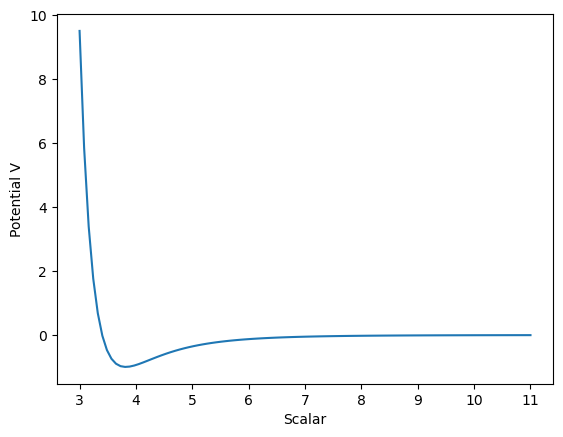

In [93]:
from LJhelperfunctions import *
import numpy as np
import matplotlib.pyplot as plt

def calculatePotential1(x):
    x0 = np.array([x, 0, 0])
    x1  = np.array([0, 0, 0])
    points = np.array([x0, x1])
    return V(points)


x = np.linspace(3, 11, 100)
y = [calculatePotential1(xi) for xi in x]

plt.plot(x, y)
plt.xlabel('Scalar')
plt.ylabel('Potential V')
plt.show()


#### (2)

In a similar manner as the previous exercise, `calculatePotential2(x)` takes in a scalar argument `x` and computes the potential but this time on the added points $x_2 = [14,0,0]$ and $x_3 = [7, 3.2, 0]$. Again, the resulting values for the same linear space as the exercise above is displayed in the output cell below.

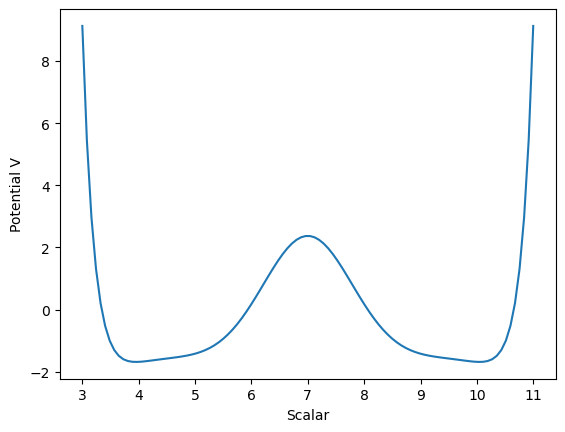

In [94]:
def calculatePotential2(x):
    x0 = np.array([x, 0, 0])
    x1  = np.array([0, 0, 0])
    x2 = np.array([14, 0, 0])
    x3 = np.array([7, 3.2, 0])
    points = np.array([x0, x1, x2, x3])
    return V(points)

x = np.linspace(3, 11, 100)
y = [calculatePotential2(xi) for xi in x]

plt.plot(x, y)
plt.xlabel('Scalar')
plt.ylabel('Potential V')
plt.show()

### Exercise b)

The *Bisection Root* algorithm is at its core, a sort of binary search algorithm running across a continous function $f$ in order to find a zero within the interval $[a, b]$. Therefore, the algorithm is pretty straightforward and can be found below in the function `bisection_root(f, a, b, tolerance)`. Following the assignment, the convergence test is made on how close $f(x)$ gets to zero, that is, we iterate until $|f(x)| < 10^{-13}$ rather than until the bracket itself becomes small.

Running this utilizing the function from exercise a1) for the initial interval $[2,6]$ yields $x = 3.4010000000000105 = \sigma$ with $|f(x)| \approx 7.44 \cdot 10^{-14} < 10^{-13}$ in 47 calls to the function $f$.


In [95]:

def bisection_root(f, a, b, tolerance=1e-13):
    assert f(a) * f(b) < 0

    y1 = f(a)
    n = 1

    while True:

        midpoint = (a + b) / 2
        y_mid = f(midpoint)
        n += 1

        if abs(y_mid) < tolerance:
            return midpoint, n

        if y1 * y_mid < 0:
            b = midpoint
        else:
            a = midpoint
            y1 = y_mid

x, n_calls = bisection_root(calculatePotential1, 2, 6)
print(f"x={x}, n_calls={n_calls}")
print(f"|f(x)|={abs(calculatePotential1(x)):.3e}")


x=3.4010000000000105, n_calls=47
|f(x)|=7.438e-14


### Exercise c)

With the *Newton-Raphson* algorithm, the approximation is continuously updated by:
$$x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}$$

Just by the expression, we can see that if the derivative happens to vanish, the guess will sky-rocket, going out of bounds for $[a,b]$.

Using the same convergence test as in exercise b), this time requiring $|f(x^*)| < 10^{-12}$, the solver reaches $x = 3.400999999999998$ with $|f(x^*)| \approx 1.06 \cdot 10^{-14}$ starting from $x_0 = 2$. This costs 25 calls, counting each evaluation of $f$ and of its derivative $f'$ as one call, which is roughly half of the 47 that bisection needed for an even tighter tolerance. This is the quadratic convergence of Newton-Raphson paying off against the merely linear convergence of bisection.


In [96]:
def newton_root(f, df, x0, tolerance, max_iterations):
    n = 0
    for k in range(max_iterations):
        y = f(x0)
        n += 1

        if abs(y) < tolerance:
            return x0, n

        x0 = x0 - y / df(x0)
        n += 1

    return x0, n

def derivative(r):
    return 4*EPSILON*(6*SIGMA**6/r**7 - 12*SIGMA**12/r**13)

x, n_calls = newton_root(calculatePotential1, derivative, 2, 1e-12, 100)
print(f"x={x}, n_calls={n_calls}")
print(f"|f(x)|={abs(calculatePotential1(x)):.3e}")


x=3.400999999999998, n_calls=25
|f(x)|=1.063e-14


### Exercise d)

We saw that *Bisection Root* is guaranteed to converge, however, *Newton-Raphson* method utilizes less calls. Utilizing a mix of these two allows us to get both of these benefits. 

The algorithm starts by a bisection root step before joining any loop. From here, we utilize Newton-Rapshon step to propose a new x, if this falls in between $[a,b]$, then we proceed with the suggestion; If not, we obtain the more certain step from bisection root. Lastly, it's a matter of checking for convergence and/or redefining the limits for the next iteration.

This algorithm returns an $x$ with an error $\lt 10^{-13}$ in merely 23 calls to both function $f$ and its derivative, which proves that we got the *guaranteed convergance* of bisection root, with the speed boost from newton-rapshon.

In [97]:
def hybrid_root(f, df, a, b, tolerance, max_iterations):

    y_a = f(a)
    x = (a + b) / 2
    y = f(x)
    n = 2

    while n < max_iterations:

        x_newton = x - y / df(x)
        n += 1
        if a < x_newton < b:
            x = x_newton
        else:
            x = (a + b) / 2

        y = f(x)
        n += 1
        if abs(y) < tolerance:
            return x, n

        if y_a * y < 0:
            b = x
        else:
            a = x
            y_a = y

    return x, n

x, n_calls = hybrid_root(calculatePotential1, derivative, 2, 6, 1e-13, 100)
print(f"x={x}, n_calls={n_calls}")

x=3.4010000000000002, n_calls=22


### Exercise e)

The gradient obtained from the same particle system as exercise a1) yields the following matrix when the scalar `x` equals 3

$$\begin{bmatrix}54.9536532 & 0 & 0 \\\ -54.9536532 & 0 & 0 \end{bmatrix}$$

As we can see, the components $y$ and $z$ are zero. The reason why this happens is because the particles $x_0$ and $x_1$ ($[x,0,0]$ and $[0,0,0]$), are only different in the $x$ component, making their difference in other axis vanish. We can also see that the non-null component $x$ has exactly opposite values. This is simply because each particle is being attracted by a force with the same scalar but opposite directions. In physics terms, we are dealing with Newton's Third Law of Motion acting on the particle pair.

In the first output cell below, we can observe the plot of the nonzro component for the derivative of the $x$-coordinate of $x_0$ and its potential. We can also realize a relationship between them: The moment the gradient passes through zero, that is $\nabla V = 0$, is the exact moment the potential reaches a minimum.


If we then try to observe this same minimum but with the 4-particle system, we can see that the gradient at that point ($x_{min} = 3.\hat{96}$) does not produce a zero gradient. The reason why this happens is because, in the first scenario, we were dealing with particles that only moved in $x$, and only plotting that $x$ to discover the minimum. This time, $x_2$ and $x_3$ have non zero $y$ components ($[14,0,0]$ and $[7, 3.2, 0]$), meaning there will always be a $y$ force that moving along the $x$ axis can never cancel.

[[-54.9536532   0.          0.       ]
 [ 54.9536532   0.          0.       ]]


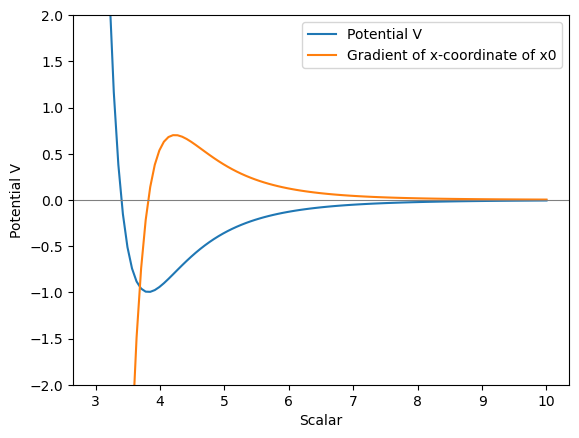

In [98]:
def calculateGradient1(x):
    x0 = np.array([x, 0, 0])
    x1 = np.array([0, 0, 0])
    points = np.array([x0, x1])
    return gradV(points)

print(calculateGradient1(3))

x = np.linspace(3, 10, 100)
y = [calculatePotential1(xi) for xi in x]
dy = [calculateGradient1(xi)[0, 0] for xi in x]

plt.plot(x, y, label='Potential V')
plt.plot(x, dy, label='Gradient of x-coordinate of x0')
plt.axhline(0, color='gray', linewidth=0.8)
plt.ylim(-2, 2)
plt.xlabel('Scalar')
plt.ylabel('Potential V')
plt.legend()
plt.show()

In [99]:
def calculateGradient2(x):
    x0 = np.array([x, 0, 0])
    x1 = np.array([0, 0, 0])
    x2 = np.array([14, 0, 0])
    x3 = np.array([7, 3.2, 0])
    points = np.array([x0, x1, x2, x3])
    return gradV(points)

x = np.linspace(3, 11, 100)
y = [calculatePotential2(xi) for xi in x]
x_min = x[np.argmin(y)]

print(f"x_min={x_min}")
print()
print(calculateGradient2(x_min))

x_min=3.9696969696969697

[[ 0.03937702 -0.48091795  0.        ]
 [-0.51949056 -0.00947811  0.        ]
 [ 0.02469881 -0.00947811  0.        ]
 [ 0.45541473  0.49987417  0.        ]]


### Exercise f)

*Line Searching* moves every particle at once along the direction $\mathbf{d}$, going over the many configurations for $\mathbf{X}_0 + \alpha \mathbf{d}$ to find a minimum. In the case of this exercise, our alpha is contained within $\alpha \in [0,1]$ and our objective is to find the point along the line that makes $\mathbf{d} \cdot \mathbf{F}(\mathbf{X}_0 + \alpha \mathbf{d}) = 0$.

For this, we utilize the bisection solver from exercise b) to find the zero in the aforementioned function, given the limits $[0,\alpha_{max}]$ which we define to be $\alpha_{max} = 1$. With this perspective in mind, the implementation is actually super simple and can be found in `linesearch` below.

Running this on `F=gradV`, $\mathbf{d} = -\nabla V_{LJ} (\mathbf{X}_0)$ where $\mathbf{X}_0$ is the stacked matrix of our particle positions:

$$\mathbf{X}_0 = \begin{bmatrix} 4&0&0 \\\ 0&0&0 \\\ 14&0&0 \\\ 7&3.2&0 \end{bmatrix}$$

We obtain a minimum $\mathbf{d} \cdot \mathbf{F}(\mathbf{X}_0 + \alpha \mathbf{d}) \approx 3.11^{-13}$ at $\alpha = 0.45170705184222015$ after 44 calls.

Despite it still not being a global minimum, the direction among this line (at least for $\alpha \in [0,1]$) as reached as low as possible, meaning that to continue our search, we would need to change $\mathbf{d}$ given the updated gradient.

In [100]:
def linesearch(F, X0, d, alpha_max, tolerance, max_iterations):

    def g(alpha):
        return np.sum(d * F(X0 + alpha * d))

    return bisection_root(g, 0, alpha_max, tolerance)

X0 = np.array([[4,0,0], 
               [0,0,0],
               [14,0,0],
               [7,3.2,0],
               ])
d = -gradV(X0)

alpha, ncalls = linesearch(gradV, X0, d, 1, 1e-13, 100)
print(f"alpha={alpha}, ncalls={ncalls}")
print(f"d*F(X0 + alpha*d)={np.sum(d * gradV(X0 + alpha * d)):2e}")

print()
print(f"V(X0)={V(X0)}, V(X0 + alpha*d)={V(X0 + alpha * d)}")

alpha=0.4517070518421633, ncalls=44
d*F(X0 + alpha*d)=-6.800116e-15

V(X0)=-1.6816165088677426, V(X0 + alpha*d)=-2.002392404932149


## Week 5

In [101]:
ar_start = np.load("ArStart.npz")

### Exercise g)

The *Golden Section* search a minimum inside the bracket in the same way bisection tracks a zero. However, suince a minimum is not detected by the same condition as a zero (i.e. a sign change), it needs two interior points to confirm. So, iteratively, new points are calculated from the previous ones by decreasing/increasing the boundary by $\phi = \frac{1 + \sqrt{5}}{2}$ which is the golden ratio.

Applying this to the same problem as in exercise f), that is, $V_{LJ}(\mathbf{X}_0 + \alpha \mathbf{d})$, we obtain $\alpha = 0.4516693913190847$ in 17 calls, matching the value by an error $\lt 10^{-3}$.

Using it on the two-particle potential to find the optimal minimal energy distance $r_0$ between two Argon atoms over a span of $[3,10]$ returns $r_0 = 3.8174168634139773$ after 21 calls.


In [102]:
def golden_section_min(f,a,b,tolerance=1e-3):
    phi = (1 + np.sqrt(5)) / 2
    r = 1/phi

    x1 = b - r * (b - a)
    x2 = a + r * (b - a)
    f1 = f(x1)
    f2 = f(x2)

    n_calls = 2

    while abs(b - a) > tolerance:
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1
            x1 = b - r * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            f1 = f2
            x2 = a + r * (b - a)
            f2 = f(x2)

        n_calls += 1

    return (a + b) / 2, n_calls


alpha, n_calls = golden_section_min(lambda a: V(X0 + a * d), 0, 1, 1e-3)
print(f"alpha={alpha}, n_calls={n_calls}")

print()

r0, n_calls = golden_section_min(calculatePotential1, 3, 10, 1e-3)
print(f"r0={r0}, n_calls={n_calls}")

alpha=0.4516693913190847, n_calls=17

r0=3.8174168634139773, n_calls=21


### Exercise h)

*BFGS* replaces an exact Hessian by an approximation built on steps that were previously taken. In the implementation I did at `BFGS(f, graf, X, tolerance, max_iterations)`, I choose the inverse Hessian path, updating the matrix as

$$H_{k+1}^{-1} = (I - \rho_k \cdot s_k \cdot y_k^T) H_{k}^{-1} (I - \rho_k \cdot y_k \cdot s_k^T) + \rho_k \cdot s_k \cdot s_k^T$$

In which $s_k = \mathbf{X}_{k+1} - \mathbf{X}_k$ and $\mathbf{y}_k = \nabla f(\mathbf{X}_{k+1}) - \nabla f(\mathbf{X}_k)$. The step to produce $\mathbf{X}_{k+1}$ is given by the basic formula $\mathbf{X}_{k+1} = \mathbf{X}_k + \alpha * \mathbf{d}$ where $\alpha$ is, for now, fixed to 1.

Feeding this function the flattened versions of the function and gradient the are given (since the algorithm works on vector products), and the initial configuration `Xstart2`, it converges to the distance $r_0=3.817493425601058$, which is in sync with the previous exercise with an error $\lt 10^{-6}$ after 13 calls.

In [103]:
def BFGS(f, gradf, X, tolerance=1e-6, max_iterations=10000):
    n = len(X)
    H = np.eye(n)
    X_k = X.copy()
    n_calls = 0

    for k in range(max_iterations):
        grad_k = gradf(X_k)
        n_calls += 1

        if np.linalg.norm(grad_k) < tolerance:
            return X_k, n_calls, True

        d_k = -H @ grad_k
        X_next = X_k + d_k

        s_k = X_next - X_k
        y_k = gradf(X_next) - grad_k

        n_calls += 1

        if np.dot(y_k, s_k) > 0:
            rho_k = 1.0 / np.dot(y_k, s_k)

            H = (np.eye(n) - rho_k * np.outer(s_k, y_k)) @ H @ (np.eye(n) - rho_k * np.outer(y_k, s_k)) + rho_k * np.outer(s_k, s_k)

        X_k = X_next

    return X_k, n_calls, False


X2 = ar_start["Xstart2"]

X_opt, n_calls, converged = BFGS(flat_V, flat_gradV, X2, tolerance=1e-6, max_iterations=10000)
print(f"converged={converged}, n_calls={n_calls}")
print(f"r={distance(X_opt.reshape(-1, 3))[0, 1]}")
print(f"r0={r0}")

converged=True, n_calls=13
r=3.817493425601058
r0=3.8174168634139773


### Exercise i)


Utilizing this function on all the configurations given in `ArStart.npz` gives us the following results ($r$ is the distance between the first two particles):

| $N$ | Converged | Calls | Distances within 1% | $r$ |
| --- | --- | --- | --- | --- |
| 2 | True | 13 | 1 | 3.817493425601058 |
| 3 | True | 7645 | 1 | 42.3905984003437 |
| 4 | True | 1463 | 0 | 4979.249671704531 |
| 5 | True | 53 | 0 | 2037.160360718476 |
| 6 | True | 573 | 0 | 684.2324533825777 |
| 7 | True | 141 | 0 | 2177.7360322293594 |
| 8 | True | 51 | 0 | 504.49652542533744 |
| 9 | True | 7 | 0 | 625.1207710523072 |

If we notice, after $N=3$ no bound has a distance within the optimal $r_0 = \sqrt[6]{2} * \sigma$ despite all of them converging. And even at $N=3$, only a single bond is preserved, with the other particle being pushed away, as we can see by the plots depicted in the output cell below. The reason why it still notes as `converged=True` is because the stopping condition only cars about the norm of $\nabla$, and when a cluster falls apart, by exploding its distances, this gradient can become small enough to break this cycle. 

In the output cell below, we can also observe the realtime it took to compute the proposed solution.

r0=3.8174934263001776
File: Xstart2, converged=True, n_calls=13
r=3.817493425601058
r0=3.8174934263001776
Distances within 1% of r0: 1
Time taken: 0.0010 seconds

File: Xstart3, converged=True, n_calls=7645
r=42.39059844273854
r0=3.8174934263001776
Distances within 1% of r0: 1
Time taken: 0.3040 seconds

File: Xstart4, converged=True, n_calls=1463
r=4979.2499106765945
r0=3.8174934263001776
Distances within 1% of r0: 0
Time taken: 0.0605 seconds

File: Xstart5, converged=True, n_calls=53
r=2037.1603603782175
r0=3.8174934263001776
Distances within 1% of r0: 0
Time taken: 0.0031 seconds

File: Xstart6, converged=True, n_calls=995
r=585.2415218452676
r0=3.8174934263001776
Distances within 1% of r0: 0
Time taken: 0.0452 seconds

File: Xstart7, converged=True, n_calls=163
r=4032.8546169032957
r0=3.8174934263001776
Distances within 1% of r0: 0
Time taken: 0.0112 seconds

File: Xstart8, converged=True, n_calls=51
r=500.31091746021906
r0=3.8174934263001776
Distances within 1% of r0: 0
Time take

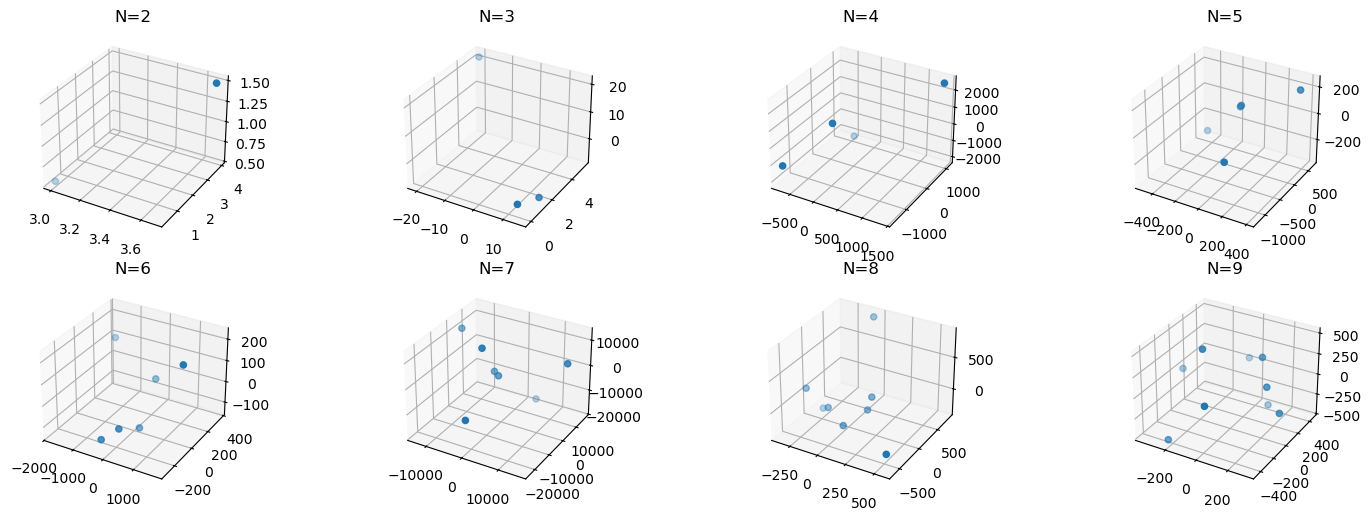

In [104]:
import time

files = ['Xstart2', 'Xstart3', 'Xstart4', 'Xstart5', 'Xstart6', 'Xstart7', 'Xstart8', 'Xstart9']

r0 = 2**(1/6) * SIGMA
print(f"r0={r0}")

fig, ax = plt.subplots(ncols=4,nrows=2,figsize=(18,6),subplot_kw=dict(projection='3d'))
ax = ax.flatten()

for i, file in enumerate(files):
    t0 = time.time()
    X = ar_start[file]
    X_opt, n_calls, converged = BFGS(flat_V, flat_gradV, X, tolerance=1e-6, max_iterations=10000)

    distance_matrix = distance(X_opt.reshape(-1, 3))
    bonds = sum(abs(distance_matrix-r0)/r0 <= 0.02)//2

    print(f"File: {file}, converged={converged}, n_calls={n_calls}")
    print(f"r={distance(X_opt.reshape(-1, 3))[0, 1]}")
    print(f"r0={r0}")

    print(f"Distances within 1% of r0: {bonds}")
    print(f"Time taken: {time.time() - t0:.4f} seconds")
    print()


    pos_mat = X_opt.reshape(-1, 3)

    ax[i].scatter(pos_mat[:,0], pos_mat[:,1], pos_mat[:,2])
    ax[i].set_title(f'N={i+2}')


### Exercise j)

Instead of taking a fixed step at every direction that we move in the gradient, we can instead leverage the previously worked on `golden_section` to find an optimal $\alpha \in [0,1]$ that we can use to more carefully drive around, preventing the algorithm from leaving the region where the potential is still decreasing, making clusters behave properly iinstead of exploding. Below, are the results for the same configurations as the previous exercise but with this change in mind ($r$ means the distance from the first to second particle, don't pay much attention):

| $N$ | Converged | Calls | Distances within 1% | $r$ |
| --- | --- | --- | --- | --- |
| 2 | True | 58 | 1 | 3.817493429100796 |
| 3 | True | 286 | 3 | 3.8174934463288333 |
| 4 | True | 381 | 6 | 3.81749345131858 |
| 5 | True | 4295 | 9 | 3.8095030006428496 |
| 6 | True | 5188 | 12 | 3.8104123853546015 |
| 7 | True | 77 | 0 | 532.1660763255373 |
| 8 | True | 13985 | 18 | 3.7870584174361834 |
| 9 | True | 7468 | 22 | 3.7749487138213325 |


Compared to what we ould solve before, with th integration of line search, all the configuration except for $N=7$ have at least one bond within the optimal threshold. The drawback with this modifiation is simply the number of calls that we need to perform due to the golden section search, reaching almost 14k for the second-to-last configuration.

In the output cell below, we can also observe the realtime it took to compute the proposed solution.

In [105]:
def BFGS_LS(f, gradf, X, tolerance=1e-6, max_iterations=10000):
    n = len(X)
    H = np.eye(n)
    X_k = X.copy()
    n_calls = 0

    for k in range(max_iterations):
        grad_k = gradf(X_k)
        n_calls += 1

        if np.linalg.norm(grad_k) < tolerance:
            return X_k, n_calls, True

        d_k = -H @ grad_k

        alpha, ls_calls = golden_section_min(lambda a: f(X_k + a * d_k), 0, 1, tolerance=1e-3)

        n_calls += ls_calls

        X_next = X_k + alpha * d_k

        s_k = X_next - X_k
        y_k = gradf(X_next) - grad_k

        n_calls += 1

        if np.dot(y_k, s_k) > 0:
            rho_k = 1.0 / np.dot(y_k, s_k)

            H = (np.eye(n) - rho_k * np.outer(s_k, y_k)) @ H @ (np.eye(n) - rho_k * np.outer(y_k, s_k)) + rho_k * np.outer(s_k, s_k)

        X_k = X_next

    return X_k, n_calls, False

r0=3.8174934263001776
File: Xstart2, converged=True, n_calls=58
r=3.817493429100796
r0=3.8174934263001776
Distances within 1% of r0: 1
Time taken: 0.0020 seconds

File: Xstart3, converged=True, n_calls=286
r=3.817493446328892
r0=3.8174934263001776
Distances within 1% of r0: 3
Time taken: 0.0090 seconds

File: Xstart4, converged=True, n_calls=381
r=3.8174934513170005
r0=3.8174934263001776
Distances within 1% of r0: 6
Time taken: 0.0121 seconds

File: Xstart5, converged=True, n_calls=2718
r=3.8095029650223484
r0=3.8174934263001776
Distances within 1% of r0: 9
Time taken: 0.0895 seconds

File: Xstart6, converged=True, n_calls=5188
r=3.810412320307523
r0=3.8174934263001776
Distances within 1% of r0: 12
Time taken: 0.1994 seconds

File: Xstart7, converged=True, n_calls=77
r=532.166076271721
r0=3.8174934263001776
Distances within 1% of r0: 0
Time taken: 0.0042 seconds

File: Xstart8, converged=True, n_calls=1654
r=74896.9013753862
r0=3.8174934263001776
Distances within 1% of r0: 0
Time taken

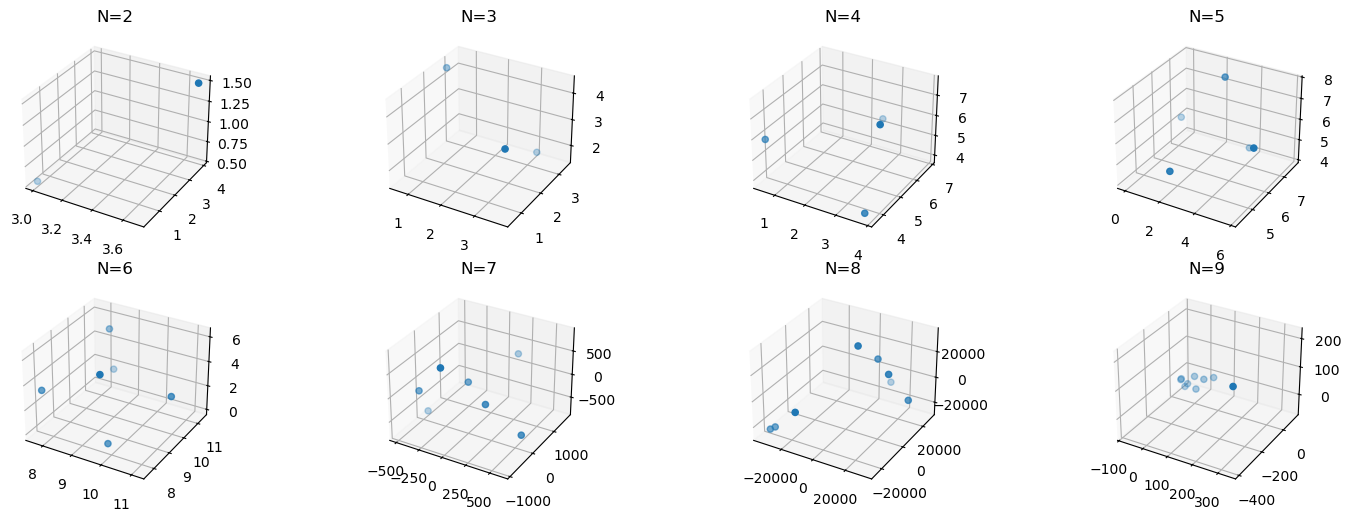

In [106]:


files = ['Xstart2', 'Xstart3', 'Xstart4', 'Xstart5', 'Xstart6', 'Xstart7', 'Xstart8', 'Xstart9']

r0 = 2**(1/6) * SIGMA
print(f"r0={r0}")

fig, ax = plt.subplots(ncols=4,nrows=2,figsize=(18,6),subplot_kw=dict(projection='3d'))
ax = ax.flatten()

for i, file in enumerate(files):
    t0 = time.time()

    X = ar_start[file]
    X_opt, n_calls, converged = BFGS_LS(flat_V, flat_gradV, X, tolerance=1e-6, max_iterations=10000)

    distance_matrix = distance(X_opt.reshape(-1, 3))
    bonds = sum(abs(distance_matrix-r0)/r0 <= 0.02)//2

    print(f"File: {file}, converged={converged}, n_calls={n_calls}")
    print(f"r={distance(X_opt.reshape(-1, 3))[0, 1]}")
    print(f"r0={r0}")

    print(f"Distances within 1% of r0: {bonds}")
    print(f"Time taken: {time.time() - t0:.4f} seconds")
    print()


    pos_mat = X_opt.reshape(-1, 3)

    ax[i].scatter(pos_mat[:,0], pos_mat[:,1], pos_mat[:,2])
    ax[i].set_title(f'N={i+2}')